# AI-Powered Sales Forecasting Assistant

This project learns the pattern in past sales, predicts the next 90 days, and then lets you *ask questions about the forecast in plain English* and get a written answer back.

There are two halves, and it's worth keeping them separate in your head:

| Half | What it is | Who does the work |
|---|---|---|
| **The forecaster** | A machine learning model that turns dates + promotions into a number | scikit-learn (math, not "AI chat") |
| **The assistant** | A layer that reads the forecast and explains it in English | A language model (Claude), with an offline fallback |

- The **forecaster** produces the *numbers*. 
- The **assistant** produces the *words*. 

**Requirements:** It can works with **no API key and no internet** — the assistant falls back to a rule-based version. If you add an API key it gets smarter. 

---

## Step 1 — Setup

Import the libraries and fix the random seed. Fixing the seed means the "random" sample data comes out **identical every time you run it**, so your numbers match what's in your report. 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.base import clone
import os, json, urllib.request

print("Import complete.")



Import complete.


In [21]:
import os
from dotenv import load_dotenv

# Load all variables from the local .env file
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [5]:

# Fixed seed -> same "random" data every run -> reproducible results
SEED = 42
rng = np.random.default_rng(SEED)

# Chart styling
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

HORIZON = 90          # how many days ahead we forecast
TEST_DAYS = 90        # how many days we hide from the model to grade it

## Step 2 — Create the sample data

We **simulate** data. 

The advantage of simulated data is that we know the ground truth. We are *baking in* four real-world patterns, then checking whether the model can rediscover them:

1. **Trend** — the business is slowly growing.
2. **Yearly seasonality** — a big Q4 holiday-shopping lift.
3. **Weekly seasonality** — weekends are busier than midweek.
4. **Promotions** — on promo days, sales jump ~35%.
5. **Noise** — random day-to-day chaos that *nothing* can predict. This is important: it sets a ceiling on how accurate any model can possibly be.

This gives us 4 years of daily revenue for a fictional online store.

In [6]:
START, END = "2022-01-01", "2025-12-31"
dates = pd.date_range(START, END, freq="D")
n = len(dates)
t = np.arange(n)                      # 0, 1, 2, ... a simple time counter

# --- the ingredients we bake in ---
base   = 1000                                            # average daily revenue at day 0
trend  = 0.45 * t                                        # steady growth over time
yearly = 220 * np.sin(2 * np.pi * (dates.dayofyear - 80) / 365.25)   # annual wave
q4_lift = np.where(dates.month.isin([11, 12]), 350, 0)   # extra holiday-season boost
weekly = np.where(dates.dayofweek >= 5, 180, 0)          # Sat/Sun are busier
payday = np.where(dates.day.isin([1, 15]), 90, 0)        # small payday bump

promo = rng.binomial(1, 0.10, n)                         # ~10% of days have a promotion
promo_effect = promo * 0.35                              # promos add 35%

signal = (base + trend + yearly + q4_lift + weekly + payday) * (1 + promo_effect)
noise  = rng.normal(1.0, 0.07, n)                        # +/- 7% random daily noise
revenue = np.maximum(signal * noise, 50).round(2)        # revenue can't go negative

df = pd.DataFrame({"date": dates, "revenue": revenue, "promo": promo})
df.to_csv("sample_sales_data.csv", index=False)

print(f"Generated {len(df):,} days of data: {df.date.min().date()} -> {df.date.max().date()}")
df.head()

Generated 1,461 days of data: 2022-01-01 -> 2025-12-31


,date,revenue,promo
0,2022-01-01,1039.45,0
1,2022-01-02,992.61,0
2,2022-01-03,864.78,0
3,2022-01-04,798.95,0
4,2022-01-05,739.98,0


## Step 3 — Look at the data before modelling anything

Never skip this. You are checking that the patterns you *think* exist are actually visible. If you can't see a pattern with your eyes, a model will struggle to find it too.

count    1461.00
mean     1494.50
std       338.42
min       644.62
25%      1264.14
50%      1469.64
75%      1692.96
max      2899.26


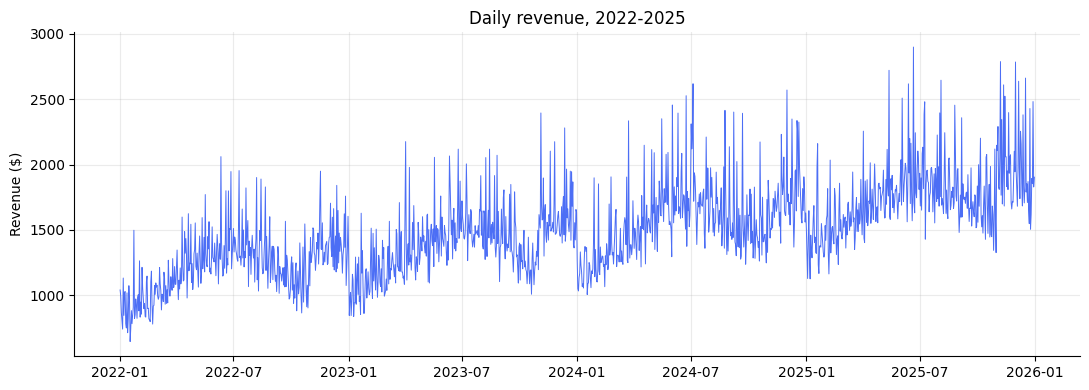

In [7]:
print(df["revenue"].describe().round(2).to_string())

fig, ax = plt.subplots()
ax.plot(df["date"], df["revenue"], lw=0.7, color="#4C6EF5")
ax.set_title("Daily revenue, 2022-2025")
ax.set_ylabel("Revenue ($)")
plt.tight_layout(); plt.show()

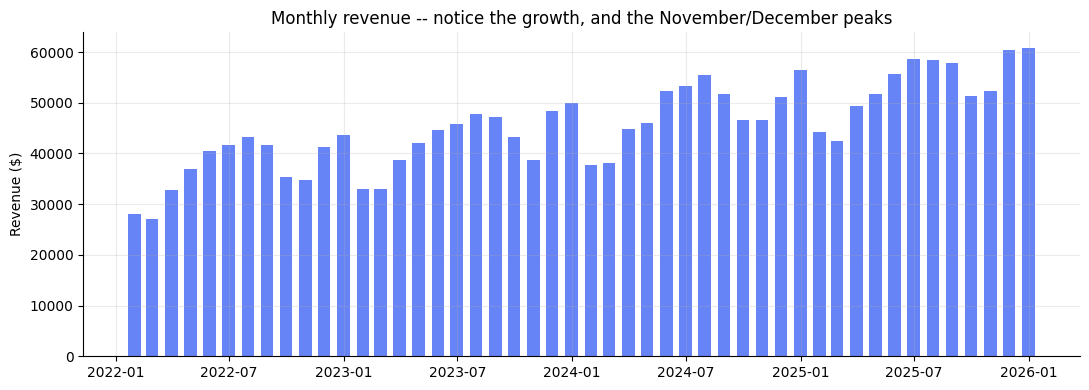

In [8]:
# Zoom out to monthly totals -- the trend and the Q4 spike become obvious
monthly = df.set_index("date")["revenue"].resample("ME").sum()

fig, ax = plt.subplots()
ax.bar(monthly.index, monthly.values, width=20, color="#4C6EF5", alpha=0.85)
ax.set_title("Monthly revenue -- notice the growth, and the November/December peaks")
ax.set_ylabel("Revenue ($)")
plt.tight_layout(); plt.show()

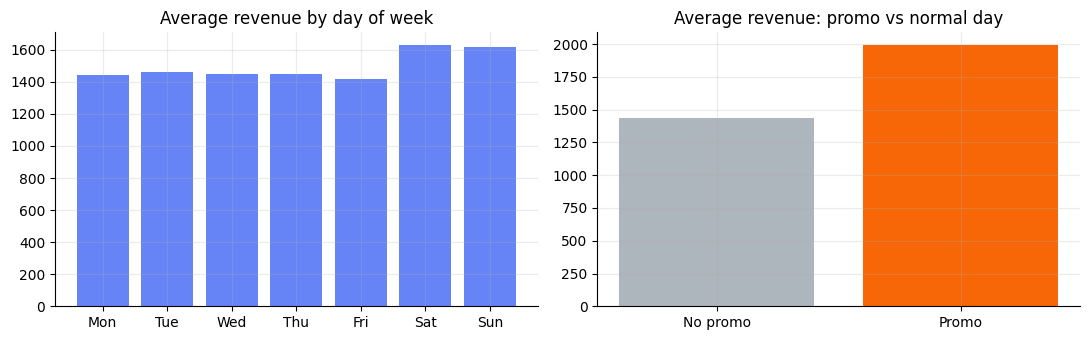

Weekend days average 12% more than weekdays.
Promo days average 38% more than normal days.


In [9]:
# Average by day of week, and promo vs non-promo days
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
by_dow = df.groupby(df["date"].dt.dayofweek)["revenue"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(days, by_dow.values, color="#4C6EF5", alpha=0.85)
axes[0].set_title("Average revenue by day of week")

by_promo = df.groupby("promo")["revenue"].mean()
axes[1].bar(["No promo", "Promo"], by_promo.values, color=["#ADB5BD", "#F76707"])
axes[1].set_title("Average revenue: promo vs normal day")
plt.tight_layout(); plt.show()

lift = (by_promo[1] / by_promo[0] - 1) * 100
print(f"Weekend days average {by_dow[5:].mean()/by_dow[:5].mean()*100 - 100:.0f}% more than weekdays.")
print(f"Promo days average {lift:.0f}% more than normal days.")

## Step 4 — Feature engineering (turning a date into numbers)

A model can't read a date. It needs a table of numbers. So we translate each day into **features** — the clues the model is allowed to use:

**Calendar features** (known in advance, forever):
- day of week, month, is it a weekend
- a time counter for the growth trend
- `sin`/`cos` of the day of year — a smooth way to encode "where are we in the annual cycle", so the model knows Dec 31 and Jan 1 are *next to each other* rather than 364 days apart

**Business features:**
- `promo` — was there a promotion

**Lag features** (what recently happened):
- revenue 7, 14 and 28 days ago, and the 7-day and 28-day rolling average

Lags are extremely powerful — the best clue for tomorrow is usually last week. But they come with a catch we deal with in Step 8: to predict 60 days out, you need to already know what happened 53 days out. We solve that by predicting one day at a time and feeding each prediction back in.

In [10]:
def make_features(data: pd.DataFrame) -> pd.DataFrame:
    """Turn a date + promo table into the numeric features the model learns from."""
    out = data.copy()
    d = out["date"]

    # calendar
    out["dayofweek"]  = d.dt.dayofweek
    out["month"]      = d.dt.month
    out["day"]        = d.dt.day
    out["is_weekend"] = (d.dt.dayofweek >= 5).astype(int)
    out["is_q4"]      = d.dt.month.isin([11, 12]).astype(int)
    out["time_idx"]   = (d - pd.Timestamp(START)).dt.days      # the trend
    doy = d.dt.dayofyear
    out["yr_sin"] = np.sin(2 * np.pi * doy / 365.25)           # annual cycle
    out["yr_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # lags: what revenue looked like recently
    out["lag_7"]   = out["revenue"].shift(7)
    out["lag_14"]  = out["revenue"].shift(14)
    out["lag_28"]  = out["revenue"].shift(28)
    out["roll_7"]  = out["revenue"].shift(7).rolling(7).mean()
    out["roll_28"] = out["revenue"].shift(7).rolling(28).mean()
    return out

FEATURES = ["dayofweek","month","day","is_weekend","is_q4","time_idx",
            "yr_sin","yr_cos","promo","lag_7","lag_14","lag_28","roll_7","roll_28"]

feat = make_features(df).dropna().reset_index(drop=True)   # first 34 days lost to lags
print(f"{len(feat):,} usable rows, {len(FEATURES)} features")
feat[["date","revenue"] + FEATURES].head(3)

1,427 usable rows, 14 features


,date,revenue,dayofweek,month,day,is_weekend,is_q4,time_idx,yr_sin,yr_cos,promo,lag_7,lag_14,lag_28,roll_7,roll_28
0,2022-02-04,854.62,4,2,4,0,0,34,0.566362,0.824157,0,822.53,842.87,844.69,970.591429,902.185714
1,2022-02-05,1212.84,5,2,5,1,0,35,0.580455,0.814292,0,980.92,906.80,1019.87,981.180000,900.095357
2,2022-02-06,1054.56,6,2,6,1,0,36,0.594376,0.804187,0,1002.92,1496.54,1027.87,910.662857,900.463571


## Step 5 — Split the data by time (not randomly)


For most machine-learning problems you shuffle your rows and split randomly. 

**For time series you must not shuffle.** If you shuffle, the model gets to train on Friday and Sunday and then "predict" Saturday — it is peeking at the future. Your accuracy score comes back beautifully, and it's meaningless. This is called **data leakage**.

So we cut the timeline in one place: everything up to the last 90 days is for **training**, and the final 90 days are hidden away as the **test set**. That test set stands in for "the future", and it's how we honestly grade the model on days it has never seen.

In [11]:
split_date = feat["date"].max() - pd.Timedelta(days=TEST_DAYS)
train = feat[feat["date"] <= split_date]
test  = feat[feat["date"] >  split_date]

X_train, y_train = train[FEATURES], train["revenue"]
X_test,  y_test  = test[FEATURES],  test["revenue"]

print(f"Train: {len(train):,} days  ({train.date.min().date()} -> {train.date.max().date()})")
print(f"Test:  {len(test):,} days  ({test.date.min().date()} -> {test.date.max().date()})   <- model never sees these")

Train: 1,337 days  (2022-02-04 -> 2025-10-02)
Test:  90 days  (2025-10-03 -> 2025-12-31)   <- model never sees these


## Step 6 — Train the models and grade them

We fit three things, deliberately from dumbest to smartest:

1. **Seasonal naive** — "next Tuesday will look like last Tuesday." No machine learning at all. This is the **baseline**, and it exists to keep us honest: if a fancy model can't beat this, the fancy model is worthless. *Always include a baseline.*
2. **Linear regression** — draws the best straight-line relationship between the features and revenue. Simple and highly explainable.
3. **Gradient boosting** — builds hundreds of small decision trees, each one fixing the previous one's mistakes. More accurate, harder to explain.

Three ways of scoring them:
- **MAE** (Mean Absolute Error): on average, how many dollars were we off by? Easiest to explain to a human.
- **RMSE**: same idea but punishes big misses much harder.
- **MAPE**: the error as a **percentage** — "we're typically within 5% of the true number." This is the one to quote to a business audience.

Lower is better on all three.

In [12]:
def score(name, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Model": name, "MAE ($)": round(mae, 1), "RMSE ($)": round(rmse, 1), "MAPE (%)": round(mape, 2)}

results, preds = [], {}

# 1. Baseline: whatever happened 7 days ago
preds["Seasonal naive"] = X_test["lag_7"].values
results.append(score("Seasonal naive (baseline)", y_test, preds["Seasonal naive"]))

# 2. Linear regression
linreg = LinearRegression().fit(X_train, y_train)
preds["Linear regression"] = linreg.predict(X_test)
results.append(score("Linear regression", y_test, preds["Linear regression"]))

# 3. Gradient boosting
gbr = GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                max_depth=3, random_state=SEED).fit(X_train, y_train)
preds["Gradient boosting"] = gbr.predict(X_test)
results.append(score("Gradient boosting", y_test, preds["Gradient boosting"]))

scoreboard = pd.DataFrame(results).sort_values("MAPE (%)")
print(scoreboard.to_string(index=False))

                    Model  MAE ($)  RMSE ($)  MAPE (%)
        Linear regression    120.8     153.9      6.40
        Gradient boosting    136.1     166.1      7.23
Seasonal naive (baseline)    313.2     419.2     16.15


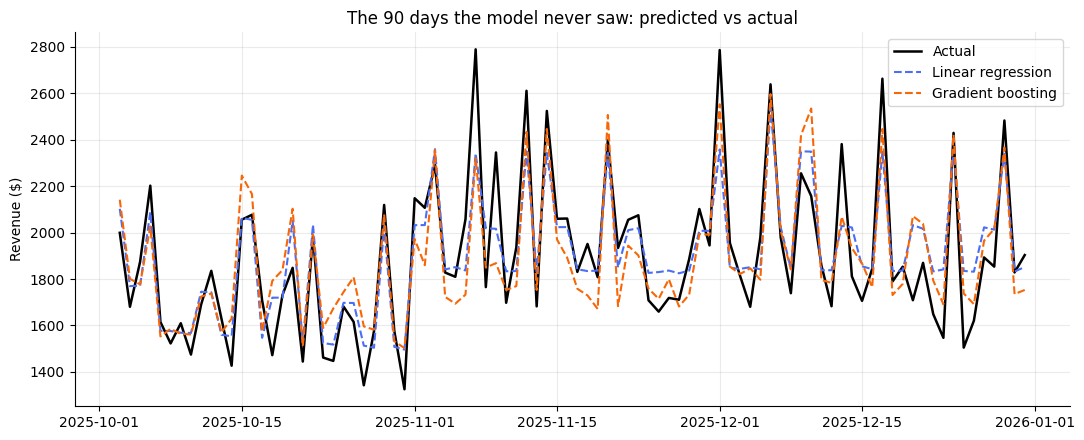

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(test["date"], y_test, label="Actual", color="black", lw=1.8)
ax.plot(test["date"], preds["Linear regression"], label="Linear regression", ls="--", color="#4C6EF5")
ax.plot(test["date"], preds["Gradient boosting"], label="Gradient boosting", ls="--", color="#F76707")
ax.set_title("The 90 days the model never saw: predicted vs actual")
ax.set_ylabel("Revenue ($)"); ax.legend()
plt.tight_layout(); plt.show()

### Observation: 
- Linear regression looks good.

## Step 7 — Why does the model say what it says?

An accurate model that nobody understands doesn't get adopted. So we open it up.

Linear regression hands us a **coefficient** per feature — literally "one unit more of this feature moves revenue by $X." Gradient boosting hands us **feature importances** — how much each clue was actually leaned on.

The thing to check: **do these match the patterns we baked into the data in Step 2?** If the model says promotions and the annual cycle matter most, it has genuinely rediscovered the truth on its own. That's your validation.

**Note the result on the scoreboard above — the simple linear regression beat the fancy gradient booster.** That is not a mistake, and it's worth pointing out in your write-up. We *built* this data out of straight-line ingredients (a linear trend, fixed promo lift, fixed weekend lift), so a straight-line model is exactly the right tool. Gradient boosting is more flexible, and that flexibility is wasted — even slightly harmful — when the truth is simple. **The most complicated model is not automatically the best one.** Choosing the model that fits the shape of your problem, and proving it with a baseline, is the actual skill.

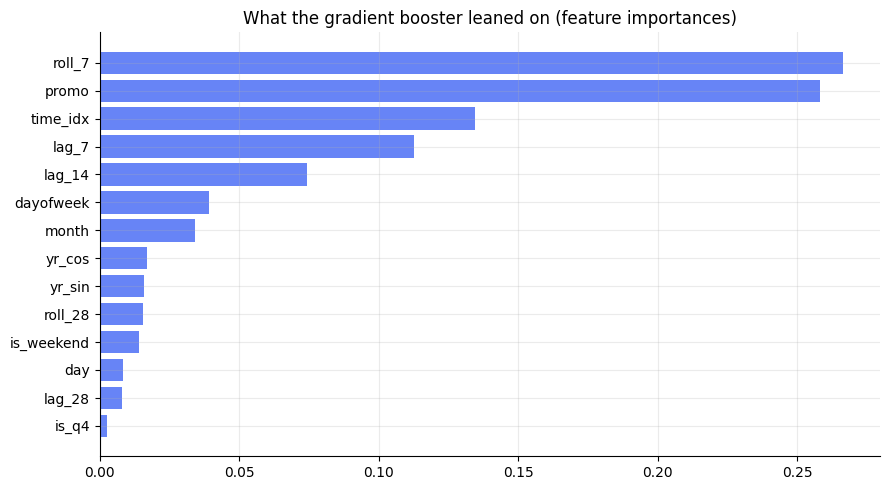

Linear regression coefficients ('$ change in revenue per 1 unit of this feature'):

promo         509.1
is_q4         332.7
yr_cos       -196.7
is_weekend    181.5
yr_sin         54.4
month           2.6

-> The model learned that a promotion adds ~$509/day, Q4 adds ~$333/day,
   and a weekend adds ~$181/day -- entirely on its own, from the raw numbers.
-> Compare that with the effects we deliberately baked in at Step 2. It rediscovered the truth.

WINNER on the test set: Linear regression  (MAPE 6.4%)


In [14]:
def top_drivers(model, k=4) -> pd.Series:
    """Works for both model types: importances for trees, |coefficients| for linear."""
    if hasattr(model, "feature_importances_"):
        vals = model.feature_importances_
    else:
        vals = np.abs(model.coef_) / np.abs(model.coef_).sum()   # normalise so they're comparable
    return pd.Series(vals, index=FEATURES).sort_values(ascending=False).head(k)

# Whichever model scored best on the unseen test data is the one we carry forward
best_name  = scoreboard.iloc[0]["Model"]
best_model = linreg if "Linear" in best_name else gbr

imp = pd.Series(gbr.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.index, imp.values, color="#4C6EF5", alpha=0.85)
ax.set_title("What the gradient booster leaned on (feature importances)")
plt.tight_layout(); plt.show()

coefs = pd.Series(linreg.coef_, index=FEATURES).sort_values(key=abs, ascending=False)
print("Linear regression coefficients ('$ change in revenue per 1 unit of this feature'):\n")
print(coefs.round(1).head(6).to_string())
print(f"\n-> The model learned that a promotion adds ~${coefs['promo']:,.0f}/day, Q4 adds ~${coefs['is_q4']:,.0f}/day,")
print(f"   and a weekend adds ~${coefs['is_weekend']:,.0f}/day -- entirely on its own, from the raw numbers.")
print(f"-> Compare that with the effects we deliberately baked in at Step 2. It rediscovered the truth.")
print(f"\nWINNER on the test set: {best_name}  (MAPE {scoreboard.iloc[0]['MAPE (%)']}%)")

## Step 8 — Forecast the next 90 days

Two things happen here.

**First, retrain on *everything*.** The test set has done its job (grading the model), so now we let the model learn from those 90 days too. You always want your final, deployed model to have seen the most recent data.

**Second, the recursion problem.** To predict day 60 in the future, the model wants to know `lag_7` — revenue on day 53 — which hasn't happened yet. So we forecast **one day at a time**, and each prediction gets appended to the history and used as the input for the next day. Predictions build on predictions. This is exactly why forecast error grows the further out you go, and it's why nobody trusts a 2-year daily forecast.

**Uncertainty.** A single number ("day 47 will be $2,113") is false precision. We measure how wrong the model was on the test set, and use that spread to draw a band around the forecast: roughly *"we're 95% confident the true value lands in here."* Presenting a range instead of a point estimate is the mark of someone who actually understands forecasting.

In [15]:
from sklearn.base import clone

# Retrain the WINNING model type on ALL available data (including the old test set)
final_model = clone(best_model).fit(feat[FEATURES], feat["revenue"])
print(f"Final model: {best_name}, retrained on all {len(feat):,} days.")

# Future promo calendar. In a real company, marketing gives you this. We assume 10% of days.
future_dates = pd.date_range(df["date"].max() + pd.Timedelta(days=1), periods=HORIZON, freq="D")
future = pd.DataFrame({"date": future_dates,
                       "revenue": np.nan,
                       "promo": rng.binomial(1, 0.10, HORIZON)})

# Recursive forecasting: predict one day, feed it back in, predict the next
history = pd.concat([df, future], ignore_index=True)
first_future = len(df)

for i in range(first_future, len(history)):
    row = make_features(history.iloc[: i + 1]).iloc[[-1]]
    history.loc[i, "revenue"] = final_model.predict(row[FEATURES])[0]

forecast = history.iloc[first_future:].copy()

# Uncertainty band, from how wrong the best model was on the unseen test data
resid_std = np.std(y_test - preds[best_name.replace(" (baseline)", "")])
forecast["lower"] = forecast["revenue"] - 1.96 * resid_std
forecast["upper"] = forecast["revenue"] + 1.96 * resid_std
forecast = forecast.rename(columns={"revenue": "forecast"})
out_cols = ["date","promo","forecast","lower","upper"]
forecast[out_cols].round({"forecast":2,"lower":2,"upper":2}).to_csv("forecast_next_90_days.csv", index=False)

print(f"Forecast horizon: {forecast.date.min().date()} -> {forecast.date.max().date()}")
print(f"Total forecast revenue: ${forecast['forecast'].sum():,.0f}")
print(f"Typical daily uncertainty: +/- ${1.96*resid_std:,.0f}")
forecast[out_cols].head().round({"forecast":2,"lower":2,"upper":2})

Final model: Linear regression, retrained on all 1,427 days.
Forecast horizon: 2026-01-01 -> 2026-03-31
Total forecast revenue: $151,829
Typical daily uncertainty: +/- $301


,date,promo,forecast,lower,upper
1461,2026-01-01,0,1492.82,1191.95,1793.69
1462,2026-01-02,1,2016.40,1715.53,2317.27
1463,2026-01-03,0,1673.63,1372.76,1974.49
1464,2026-01-04,0,1676.04,1375.17,1976.90
1465,2026-01-05,0,1499.39,1198.52,1800.26


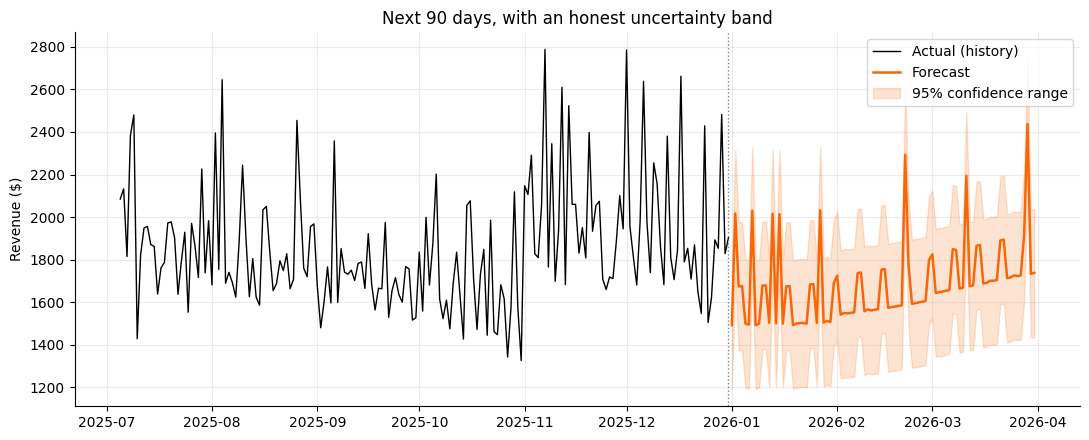

In [16]:
recent = df[df["date"] > df["date"].max() - pd.Timedelta(days=180)]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(recent["date"], recent["revenue"], color="black", lw=1, label="Actual (history)")
ax.plot(forecast["date"], forecast["forecast"], color="#F76707", lw=1.8, label="Forecast")
ax.fill_between(forecast["date"], forecast["lower"], forecast["upper"],
                color="#F76707", alpha=0.18, label="95% confidence range")
ax.axvline(df["date"].max(), color="grey", ls=":", lw=1)
ax.set_title("Next 90 days, with an honest uncertainty band")
ax.set_ylabel("Revenue ($)"); ax.legend()
plt.tight_layout(); plt.show()

## Step 9 — The AI assistant layer

Everything above is *statistics*. This is the part that makes it an **assistant**.

The idea is simple and it's how most "AI-powered" business tools actually work under the hood:

1. Package the important facts — history, accuracy scores, the forecast, what drives sales — into a compact text summary (the **context**).
2. Send that context plus the user's plain-English question to a language model.
3. The language model writes the answer *grounded in the numbers we gave it*.

**The critical design decision:** the language model does **not** invent the forecast. It never does arithmetic we depend on. It only *explains numbers that scikit-learn already computed*. If you let a chatbot guess at next quarter's revenue, it will confidently make something up — that's a hallucination, and it's the number one criticism of AI in analytics. Feeding it verified numbers and asking only for interpretation is what makes this trustworthy. **Say this sentence to your professor.**

The `ask()` function below uses Claude if you provide an API key, and otherwise falls back to a rule-based responder so the notebook always runs.

In [19]:
import os, json, urllib.request

def build_context() -> str:
    """Package the verified numbers into a factual briefing for the language model."""
    last_90 = df.tail(90)["revenue"].sum()
    next_90 = forecast["forecast"].sum()
    growth  = (next_90 / last_90 - 1) * 100
    top_feats = ", ".join(top_drivers(final_model, 4).index)
    by_month = forecast.groupby(forecast["date"].dt.to_period("M"))["forecast"].sum()

    return f"""
DATA: Daily revenue, {df.date.min().date()} to {df.date.max().date()} ({len(df):,} days).
Historical daily average: ${df.revenue.mean():,.0f}. Best day: ${df.revenue.max():,.0f}.
Weekends run ~{by_dow[5:].mean()/by_dow[:5].mean()*100-100:.0f}% above weekdays.
Promotion days run ~{lift:.0f}% above normal days.

MODEL: {best_name}, trained on calendar, promotion and lag features.
Accuracy on 90 days of held-out data it never saw: MAPE {scoreboard.iloc[0]['MAPE (%)']}%, MAE ${scoreboard.iloc[0]['MAE ($)']:,.0f}.
Beat the seasonal-naive baseline (MAPE {[r for r in results if 'naive' in r['Model']][0]['MAPE (%)']}%).
Strongest drivers, in order: {top_feats}.

FORECAST: next {HORIZON} days, {forecast.date.min().date()} to {forecast.date.max().date()}.
Total forecast revenue: ${next_90:,.0f} (previous 90 days actual: ${last_90:,.0f}, change {growth:+.1f}%).
Forecast daily average: ${forecast.forecast.mean():,.0f}, range ${forecast.forecast.min():,.0f} to ${forecast.forecast.max():,.0f}.
Uncertainty: +/- ${1.96*resid_std:,.0f} per day at 95% confidence.
By month: {'; '.join(f'{k}: ${v:,.0f}' for k, v in by_month.items())}
""".strip()

CONTEXT = build_context()
print(CONTEXT)

DATA: Daily revenue, 2022-01-01 to 2025-12-31 (1,461 days).
Historical daily average: $1,494. Best day: $2,899.
Weekends run ~12% above weekdays.
Promotion days run ~38% above normal days.

MODEL: Linear regression, trained on calendar, promotion and lag features.
Accuracy on 90 days of held-out data it never saw: MAPE 6.4%, MAE $121.
Beat the seasonal-naive baseline (MAPE 16.15%).
Strongest drivers, in order: promo, is_q4, yr_cos, is_weekend.

FORECAST: next 90 days, 2026-01-01 to 2026-03-31.
Total forecast revenue: $151,829 (previous 90 days actual: $170,365, change -10.9%).
Forecast daily average: $1,687, range $1,492 to $2,437.
Uncertainty: +/- $301 per day at 95% confidence.
By month: 2026-01: $50,727; 2026-02: $46,024; 2026-03: $55,078


In [18]:
# import os, json, urllib.request

# SYSTEM_PROMPT = (
#     "You are a sales forecasting analyst. Answer ONLY using the figures in the briefing below. "
#     "Never invent numbers. If the briefing does not contain the answer, say so plainly. "
#     "Be concise, use plain English, and always mention the uncertainty when giving a forward-looking number.\n\n"
#     + CONTEXT
# )

# def ask(question: str) -> str:
#     """Send the verified numbers + the question to Claude. Requires ANTHROPIC_API_KEY."""
#     key = os.environ.get("ANTHROPIC_API_KEY")
#     if not key:
#         raise RuntimeError("no api key")
#     req = urllib.request.Request(
#         "https://api.anthropic.com/v1/messages",
#         data=json.dumps({
#             "model": "claude-sonnet-5",          # swap for any current model name
#             "max_tokens": 500,
#             "system": SYSTEM_PROMPT,
#             "messages": [{"role": "user", "content": question}],
#         }).encode(),
#         headers={"content-type": "application/json",
#                  "x-api-key": key,
#                  "anthropic-version": "2023-06-01"},
#     )
#     with urllib.request.urlopen(req, timeout=30) as r:
#         body = json.loads(r.read())
#     return "".join(b["text"] for b in body["content"] if b["type"] == "text")



# print("Assistant ready. Ask it anything with ask('...')")

NameError: name 'CONTEXT' is not defined

In [30]:
import os
import json
import urllib.request


SYSTEM_PROMPT = (
    "You are a sales forecasting analyst. "
    "Answer ONLY using the figures in the briefing below. "
    "Never invent numbers. If the briefing does not contain the answer, "
    "say so plainly. Be concise.\n\n"
    + CONTEXT
)

def ask(question: str) -> str:
    key = os.environ.get("OPENAI_API_KEY")
    if not key:
        raise RuntimeError("OPENAI_API_KEY not found")

    payload = {
        "model": "gpt-4o-mini",
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question}
        ],
        "temperature": 0.3,
        "max_tokens": 500
    }

    req = urllib.request.Request(
        "https://api.openai.com/v1/chat/completions",
        data=json.dumps(payload).encode(),
        headers={
            "Content-Type": "application/json",
            "Authorization": f"Bearer {key}"
        }
    )

    try:
        with urllib.request.urlopen(req, timeout=30) as r:
            body = json.loads(r.read())
    except urllib.error.HTTPError as e:
        print(e.read().decode())
        raise

    return body["choices"][0]["message"]["content"]

print("Assistant ready. Ask it anything with ask('...')")

Assistant ready. Ask it anything with ask('...')


In [33]:
ask("How much revenue should we expect over the next quarter?")

'Total forecast revenue over the next quarter is $151,829.'

In [34]:
ask("How accurate is this forecast, really? Should I trust it?")

'The forecast has a MAPE of 6.4% on held-out data, which indicates good accuracy. It also has a MAE of $121. Given these figures, you can reasonably trust the forecast, especially since it beats the seasonal-naive baseline (MAPE 16.15%). However, there is an uncertainty of +/- $301 per day at 95% confidence, which should be considered when making decisions.'

In [35]:
ask("What actually drives our sales?")

'The strongest drivers of sales, in order, are: promotion, is_q4, yr_cos, and is_weekend.'

In [36]:
ask("Are promotions worth running?")

'Yes, promotions are worth running as they drive revenue significantly, running ~38% above normal days.'

## Step 10 — Limitations

- **The data is synthetic.** The model performs well partly because the patterns are cleaner than reality. Real sales data has stockouts, competitor moves, price changes and outliers.
- **Forecast error compounds.** Day 90 is far less trustworthy than day 3, because it's a prediction built on a stack of predictions.
- **The model cannot see anything it wasn't given.** No competitor launched a product, no supply chain broke, no recession happened — because none of those are columns in our table. Models only know what's in the features.
- **The past is assumed to repeat.** All forecasting rests on this. It's a good assumption right up until it catastrophically isn't (see: any business in March 2020).
- **The confidence band is approximate.** It assumes errors are evenly spread and equally sized across the horizon. They aren't — they get bigger further out.
- **The language model can only explain, not calculate.** By design. It's given verified numbers and told not to invent any. That's a safety feature, not a bug — but it means the assistant is only ever as good as the forecast underneath it.

**Sensible next steps:** try Prophet or SARIMA and compare; add real drivers (price, ad spend, weather, competitor promos); use rolling-origin cross-validation instead of a single split; forecast per product line instead of one lump total.

---



## ( TODO ) Appendix — Swapping in real sales data

Replace the Step 2 cell with a load, and everything downstream works unchanged:

```python
df = pd.read_csv("your_sales.csv", parse_dates=["date"])
df = df.rename(columns={"your_amount_column": "revenue"})
df = df.groupby("date", as_index=False)["revenue"].sum()   # one row per day
df["promo"] = 0        # or your real promotion flag
```

Requirements: one row per day, a `date` column, a `revenue` column, no gaps in the dates. If you have gaps, reindex to a full date range and fill with 0 — a day with no sales is a real data point, not a missing one.